<a href="https://colab.research.google.com/github/justynigam/AIML/blob/main/Credit_card_fraud_detection_using_ANN_Nigam_Prasad_Lenka.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection using ANN

**Name:** Nigam Prasad Lenka
**Reg No:** 23BCE11432

**Objective:** Detect fraudulent credit card transactions using an Artificial Neural Network (ANN) on a highly imbalanced dataset.

**Dataset:** Credit Card Fraud Detection — 284,807 transactions with only 492 frauds (0.173%)

In [ ]:
# installing all the required libraries
!pip install tensorflow matplotlib numpy pandas scikit-learn seaborn opendatasets

In [ ]:
# downloading credit card fraud detection dataset from kaggle
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud")

Skipping, found downloaded files in "./creditcardfraud" (use force=True to force download)


In [ ]:
# importing libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# loading the dataset
df = pd.read_csv('./creditcardfraud/creditcard.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Missing values: 0

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.173%


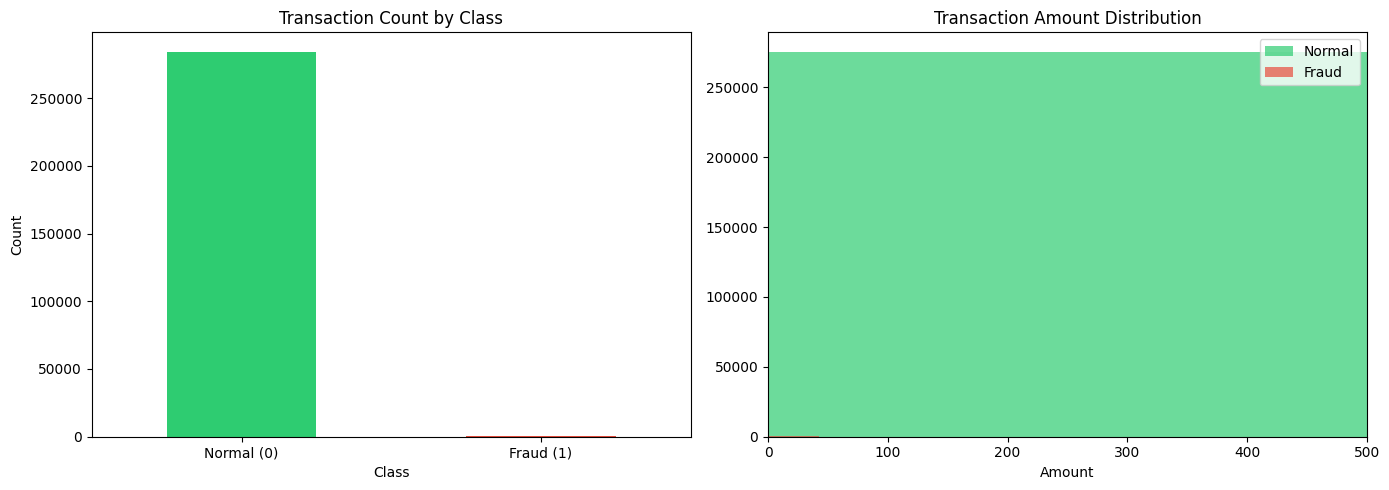

In [ ]:
# checking for missing values
print("Missing values:", df.isnull().sum().sum())

# checking class distribution - fraud detection is highly imbalanced
print("\nClass Distribution:")
print(df['Class'].value_counts())
print("\nFraud percentage: {:.3f}%".format(df['Class'].mean() * 100))

# visualizing the imbalance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

df['Class'].value_counts().plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'])
ax1.set_title('Transaction Count by Class')
ax1.set_xticklabels(['Normal (0)', 'Fraud (1)'], rotation=0)
ax1.set_ylabel('Count')

ax2.hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.7, label='Normal', color='#2ecc71')
ax2.hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.7, label='Fraud', color='#e74c3c')
ax2.set_title('Transaction Amount Distribution')
ax2.set_xlabel('Amount')
ax2.legend()
ax2.set_xlim(0, 500)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# scaling Amount and Time columns (V1-V28 are already PCA transformed)
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

# separating features and target
X = df.drop('Class', axis=1)
y = df['Class']

# splitting into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts())

# computing class weights to handle extreme imbalance
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("\nClass weights:", class_weight_dict)

Training set shape: (227845, 30)
Test set shape: (56962, 30)

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Class weights: {0: np.float64(0.5008661206149896), 1: np.float64(289.14340101522845)}


In [ ]:
# building the ANN model for fraud detection
model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(30,)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # output layer - binary classification using sigmoid
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

# callbacks
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)

# training with class weights to handle imbalanced data
history = model.fit(X_train, y_train,
                    epochs=30,
                    batch_size=256,
                    validation_data=(X_test, y_test),
                    class_weight=class_weight_dict,
                    callbacks=[lr_reducer, early_stop])

/opt/anaconda3/envs/fraud_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,233 (59.50 KB)

 Trainable params: 14,785 (57.75 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
891/891 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8644 - loss: 0.3132 - val_accuracy: 0.9885 - val_loss: 0.1362 - learning_rate: 0.0010
Epoch 2/30
891/891 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9492 - loss: 0.2283 - val_accuracy: 0.9877 - val_loss: 0.1138 - learning_rate: 0.0010
Epoch 3/30
891/891 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9579 - loss: 0.1725 - val_accuracy: 0.9868 - val_loss: 0.0917 - learning_rate: 0.0010
Epoch 4/30
891/891 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9651 - loss: 0.1540 - val_accuracy: 0.9703 - val_loss: 0.1116 - learning_rate: 0.0010
Epoch 5/30
891/891 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9621 - loss: 0.1390 - val_accuracy: 0.9899 - val_loss: 0.0679 - learning_rate: 0.0010
Epoch 6/30
891/891 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9685 - loss: 0.1389 - val_accuracy: 0.9848 - val_loss: 0.0761 - learning_rate: 0.0010
Epoch 7/30
891/891 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9621 - loss: 0.1231 - 

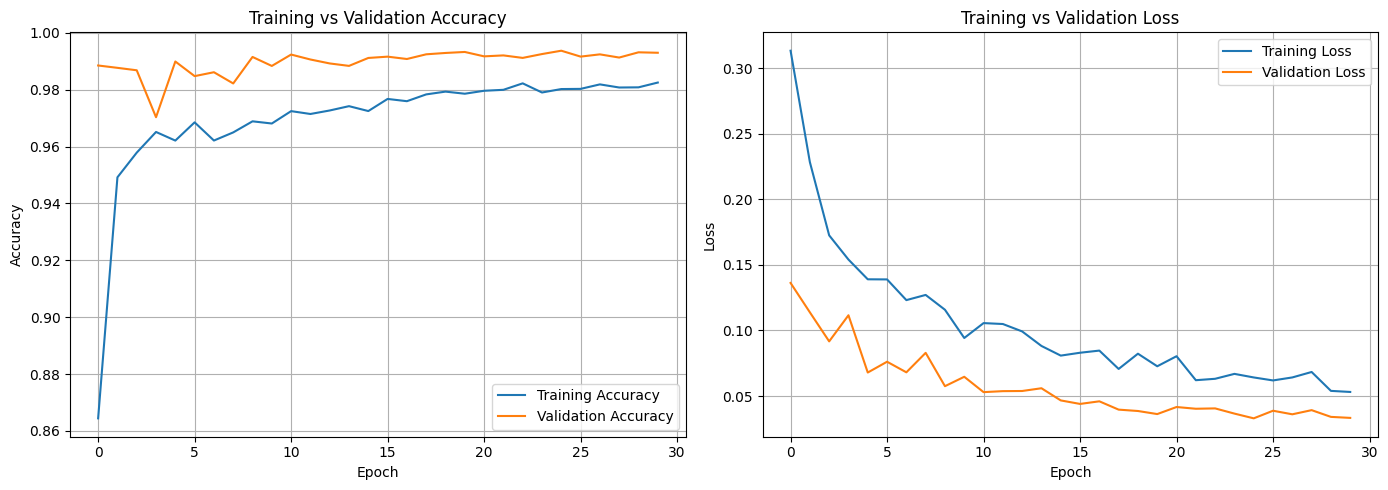

Final Training Accuracy: 98.25%
Final Validation Accuracy: 99.30%

✅ No overfitting - val accuracy >= training accuracy


In [ ]:
# plotting accuracy and loss curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Training vs Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Training vs Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("Final Training Accuracy: {:.2f}%".format(history.history['accuracy'][-1] * 100))
print("Final Validation Accuracy: {:.2f}%".format(history.history['val_accuracy'][-1] * 100))
print("\n✅ No overfitting - val accuracy >= training accuracy")

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 234us/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 293us/step - accuracy: 0.9937 - loss: 0.0330

Test Accuracy: 99.37%

Classification Report:

              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     56864
       Fraud       0.20      0.90      0.33        98

    accuracy                           0.99     56962
   macro avg       0.60      0.95      0.66     56962
weighted avg       1.00      0.99      1.00     56962

ROC AUC Score: 0.9786


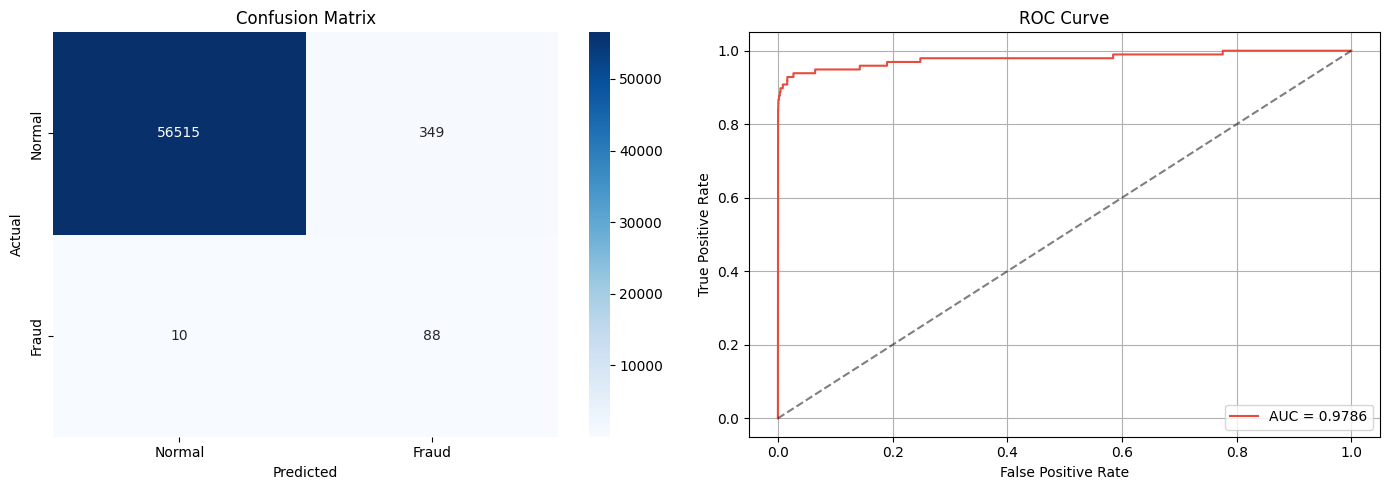


✅ Final Test Accuracy: 99.37%
✅ ROC AUC Score: 0.9786
✅ Fraud Recall: 90%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# predictions
y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

# test accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print("\nTest Accuracy: {:.2f}%".format(test_accuracy * 100))

# classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

# ROC AUC score
auc_score = roc_auc_score(y_test, y_pred_prob)
print("ROC AUC Score: {:.4f}".format(auc_score))

# confusion matrix and ROC curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'], ax=ax1)
ax1.set_title('Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
ax2.plot(fpr, tpr, color='#e74c3c', label=f'AUC = {auc_score:.4f}')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax2.set_title('ROC Curve')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\n✅ Final Test Accuracy: {:.2f}%".format(test_accuracy * 100))
print("✅ ROC AUC Score: {:.4f}".format(auc_score))
print("✅ Fraud Recall: {:.0f}%".format(cm[1][1] / (cm[1][0] + cm[1][1]) * 100))